# **3. Análisis Exploratorio de Ventas**

## **3.1 Carga de las tablas agregadas para análisis**

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

def find_project_root(start: Path, marker: str = "data", max_up: int = 6) -> Path:
    p = start.resolve()
    for _ in range(max_up):
        if (p / marker).exists():
            return p
        p = p.parent
    return start.resolve()

ROOT = find_project_root(Path.cwd())
DATA_PROCESSED = ROOT / "data" / "processed"

ts_path = DATA_PROCESSED / "ts_ventas_dia_tienda_producto.csv"
assert ts_path.exists(), "No encuentro la tabla agregada."

df_ts = pd.read_csv(ts_path, parse_dates=["FECHA"])
df_ts.head()

,FECHA,CENTRO,PLU_SAP,VENTA_BRUTA,DESCUENTO,VENTA_NETA,UNIDADES,PROMO_LINES,LINES,PRECIO_UNIT_MED,DESC_PCT_MED,PROMO_RATE,DESCUENTO_PCT_APROX,PROMO_FLAG_AGG,PRECIO_MEDIO_NETO_APROX
0,2026-01-01,1,3,36900,0.000,"36,900.000",2.061,0,1,"17,903.930",0.000,0.000,0.000,0,"17,903.930"
1,2026-01-01,1,5,143700,0.000,"143,700.000",21.285,0,3,"6,751.233",0.000,0.000,0.000,0,"6,751.233"
2,2026-01-01,1,7,60900,0.000,"60,900.000",1.968,0,2,"30,945.122",0.000,0.000,0.000,0,"30,945.122"
3,2026-01-01,1,9,17750,0.000,"17,750.000",0.771,0,1,"23,022.049",0.000,0.000,0.000,0,"23,022.049"
4,2026-01-01,1,11,24300,0.000,"24,300.000",0.804,0,2,"30,223.881",0.000,0.000,0.000,0,"30,223.881"


## **Interpretación de la Tabla Agregada – Nivel Día–Tienda–Producto**

La tabla anterior corresponde a la estructura final construida para el análisis exploratorio y modelado predictivo.  
Cada fila representa la agregación de ventas a nivel **Día – Tienda – Producto (PLU_SAP)**, lo cual constituye la granularidad recomendada para modelos de forecasting en retail.

###  Estructura y significado de las variables

- **FECHA**: Fecha calendario de la venta.
- **CENTRO**: Identificador de tienda.
- **PLU_SAP**: Código único de producto.
- **VENTA_BRUTA**: Valor total facturado antes de descuentos.
- **DESCUENTO**: Monto total descontado en ese producto ese día.
- **VENTA_NETA**: Ingreso efectivo generado (VENTA_BRUTA − DESCUENTO).
- **UNIDADES**: Cantidad total vendida (incluye ventas por peso).
- **PROMO_LINES**: Número de líneas con promoción.
- **LINES**: Número total de líneas transaccionales agregadas.
- **PROMO_RATE**: Proporción de líneas vendidas bajo promoción.
- **DESCUENTO_PCT_APROX**: Porcentaje aproximado de descuento aplicado.
- **PRECIO_MEDIO_NETO_APROX**: Precio promedio neto por unidad.
- **PROMO_FLAG_AGG**: Indicador binario de si el producto estuvo en promoción ese día.



###  Observaciones Técnicas Relevantes

1. **Coherencia en las métricas monetarias**  
   Se observa consistencia entre VENTA_BRUTA, DESCUENTO y VENTA_NETA. No se evidencian valores negativos ni descuentos superiores a la venta bruta en esta muestra.

2. **Presencia de unidades fraccionarias**  
   Las cantidades vendidas presentan valores decimales (ej. 2.061, 0.804), lo cual es típico en categorías por peso (cárnicos, frutas, etc.).  
   Esto confirma que el modelo deberá tratar correctamente ventas continuas y no solo conteos enteros.

3. **Construcción de variables estratégicas**  
   La inclusión de variables como:
   - PROMO_RATE  
   - DESCUENTO_PCT_APROX  
   - PRECIO_MEDIO_NETO_APROX  

   permite capturar efectos comerciales fundamentales para modelado predictivo avanzado.

4. **Estructura compatible con modelos secuenciales**  
   La tabla está preparada para incorporar:
   - Lags temporales
   - Ventanas móviles
   - Variables de tendencia y estacionalidad

   Esto es especialmente relevante para modelos como LSTM o arquitecturas temporales más sofisticadas.



###  Implicaciones Estratégicas

Esta estructura permite:

- Modelar ventas a nivel operativo real.
- Evaluar impacto de promociones en ingresos.
- Analizar elasticidad precio–ventas.
- Identificar productos de alta variabilidad.
- Detectar patrones específicos por tienda.

Además, esta agregación evita el ruido transaccional y convierte el dataset en una base analítica lista para modelado predictivo robusto.



###  Conclusión Ejecutiva

La construcción de esta tabla representa un paso clave hacia la implementación de modelos de predicción de ventas.  
Desde el punto de vista técnico y estructural, el dataset cumple con los requisitos mínimos para avanzar hacia:

- Modelos baseline de forecasting.
- Modelos de Machine Learning.
- Modelos Deep Learning orientados a series de tiempo.

La siguiente etapa dependerá principalmente de contar con histórico ampliado para capturar patrones temporales de largo plazo.

## **3.2 Panorama general de ventas (totales y métricas clave)**

In [12]:
summary = {
    "Total Ventas Netas": df_ts["VENTA_NETA"].sum(),
    "Total Ventas Brutas": df_ts["VENTA_BRUTA"].sum(),
    "Total Descuentos": df_ts["DESCUENTO"].sum(),
    "Total Unidades": df_ts["UNIDADES"].sum(),
    "Número de Productos": df_ts["PLU_SAP"].nunique(),
    "Número de Tiendas": df_ts["CENTRO"].nunique(),
    "Número de Fechas": df_ts["FECHA"].nunique(),
}

summary

{'Total Ventas Netas': np.float64(5621632.0),
 'Total Ventas Brutas': np.int64(5706941),
 'Total Descuentos': np.float64(85309.0),
 'Total Unidades': np.float64(299.32899999999995),
 'Número de Productos': 228,
 'Número de Tiendas': 1,
 'Número de Fechas': 1}

## **3.3 Distribución de ventas netas y unidades**

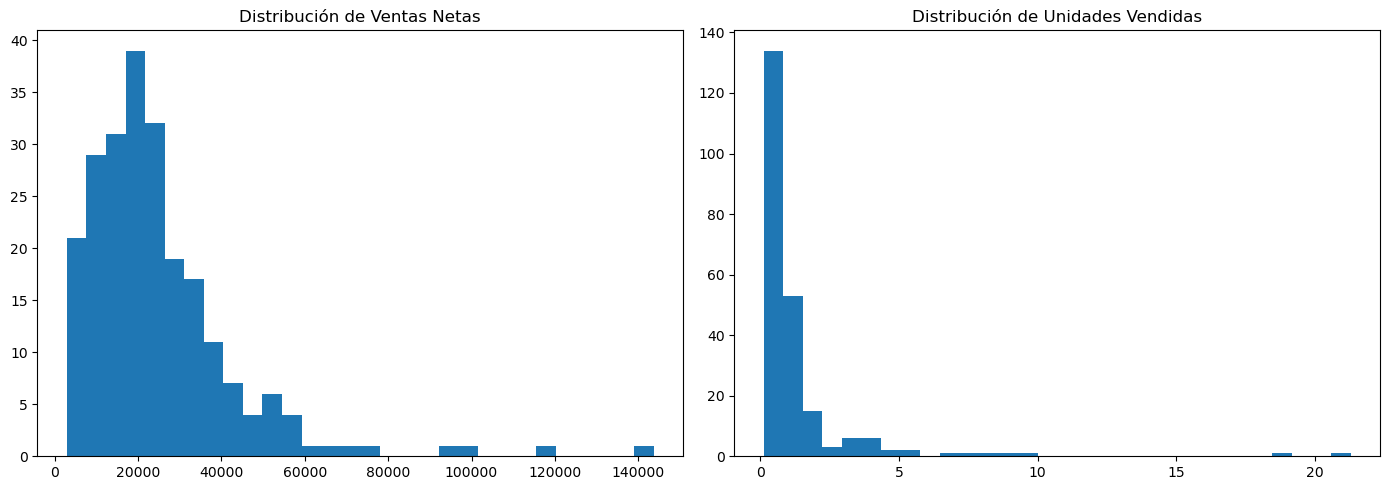

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(df_ts["VENTA_NETA"], bins=30)
axes[0].set_title("Distribución de Ventas Netas")

axes[1].hist(df_ts["UNIDADES"], bins=30)
axes[1].set_title("Distribución de Unidades Vendidas")

plt.tight_layout()
plt.show()

## **3.4 Análisis de concentración (Regla 80/20 - Pareto por producto)**

In [14]:
ventas_producto = (
    df_ts.groupby("PLU_SAP")["VENTA_NETA"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

ventas_producto["cumsum"] = ventas_producto["VENTA_NETA"].cumsum()
ventas_producto["cumsum_pct"] = ventas_producto["cumsum"] / ventas_producto["VENTA_NETA"].sum()

# ¿Cuántos productos generan 80%?
n_80 = (ventas_producto["cumsum_pct"] <= 0.8).sum()

print(f"Productos que generan el 80% de las ventas: {n_80}")
ventas_producto.head(10)

Productos que generan el 80% de las ventas: 132


,PLU_SAP,VENTA_NETA,cumsum,cumsum_pct
0,5,"143,700.000","143,700.000",0.026
1,51,"119,960.000","263,660.000",0.047
2,90,"98,910.000","362,570.000",0.064
3,139,"93,100.000","455,670.000",0.081
4,308,"77,790.000","533,460.000",0.095
5,49,"69,930.000","603,390.000",0.107
6,304,"65,980.000","669,370.000",0.119
7,7,"60,900.000","730,270.000",0.130
8,375,"56,900.000","787,170.000",0.140
9,137,"56,400.000","843,570.000",0.150


## **3.5 Top productos por ventas y por unidades**

In [15]:
top_ventas = (
    df_ts.groupby("PLU_SAP")["VENTA_NETA"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_unidades = (
    df_ts.groupby("PLU_SAP")["UNIDADES"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_ventas, top_unidades

(PLU_SAP
 5     143,700.000
 51    119,960.000
 90     98,910.000
 139    93,100.000
 308    77,790.000
 49     69,930.000
 304    65,980.000
 7      60,900.000
 375    56,900.000
 137    56,400.000
 Name: VENTA_NETA, dtype: float64,
 PLU_SAP
 5     21.285
 139   18.772
 379    9.906
 375    8.643
 248    8.320
 118    7.284
 51     6.708
 95     5.678
 19     5.402
 340    4.828
 Name: UNIDADES, dtype: float64)

## **3.6 Variabilidad de ventas (Coeficiente de variación)**

In [16]:
cv_producto = (
    df_ts.groupby("PLU_SAP")["VENTA_NETA"]
    .agg(["mean", "std"])
)

cv_producto["CV"] = cv_producto["std"] / cv_producto["mean"]
cv_producto = cv_producto.sort_values("CV", ascending=False)

cv_producto.head(10)

,mean,std,CV
PLU_SAP,,,
3,"36,900.000",NaN,NaN
5,"143,700.000",NaN,NaN
7,"60,900.000",NaN,NaN
9,"17,750.000",NaN,NaN
11,"24,300.000",NaN,NaN
13,"7,200.000",NaN,NaN
15,"17,980.000",NaN,NaN
17,"23,700.000",NaN,NaN
19,"31,400.000",NaN,NaN


## **3.7 Análisis por tienda**

In [17]:
ventas_tienda = (
    df_ts.groupby("CENTRO")["VENTA_NETA"]
    .sum()
    .sort_values(ascending=False)
)

ventas_tienda

CENTRO
1   5,621,632.000
Name: VENTA_NETA, dtype: float64

## **3.8 Análisis de facturas**

In [18]:
# Volvemos al dataset línea si lo necesitas
clean_path = DATA_PROCESSED / "Ventas_1_clean.csv"
df_line = pd.read_csv(clean_path, parse_dates=["FECHA"])

ticket_stats = (
    df_line.groupby("FACTURA")
    .agg(
        total_ticket=("VENTA_NETA", "sum"),
        productos_distintos=("PLU_SAP", "nunique"),
        total_unidades=("CANTIDAD", "sum")
    )
)

ticket_stats.describe()

,total_ticket,productos_distintos,total_unidades
count,175.000,175.000,175.000
mean,"32,123.611",1.971,1.710
std,"33,404.319",1.627,2.168
min,"1,200.000",1.000,0.088
25%,"9,895.000",1.000,0.455
50%,"21,330.000",1.000,0.959
75%,"45,225.000",2.000,2.048
max,"219,620.000",11.000,16.188


## **3.9 Conclusiones del EDA de ventas**

In [19]:
conclusiones = {
    "Venta promedio por producto": df_ts.groupby("PLU_SAP")["VENTA_NETA"].mean().mean(),
    "Descuento promedio (%)": df_ts["DESCUENTO"].sum() / df_ts["VENTA_BRUTA"].sum() if df_ts["VENTA_BRUTA"].sum() > 0 else 0,
    "Productos que dominan ventas (80%)": int(n_80),
}

conclusiones

{'Venta promedio por producto': np.float64(24656.280701754386),
 'Descuento promedio (%)': np.float64(0.01494828840879904),
 'Productos que dominan ventas (80%)': 132}